### for cifar10

In [24]:
# read summary metric for cifar10 experiment
import pandas as pd
from tabulate import tabulate
df = pd.read_csv("summary_cifar10.csv")

In [25]:
# add 1 col represent the model type (without the reg and lamb)
df["group"] = df["name"].str.split("-").str[0]
print(df["group"].unique())

['resnet20' 'resnet32' 'resnet44' 'resnet56' 'vgg11_bn' 'vgg13_bn'
 'vgg16_bn' 'vgg19_bn' 'repvgg_a0' 'repvgg_a1' 'repvgg_a2'
 'mobilenetv2_x0_5' 'mobilenetv2_x0_75' 'mobilenetv2_x1_0'
 'mobilenetv2_x1_4' 'shufflenetv2_x0_5' 'shufflenetv2_x1_0'
 'shufflenetv2_x1_5' 'shufflenetv2_x2_0']


In [26]:
def filter_group(group_df):
    # Row(s) where 'baseline' appears in the name
    baseline_rows = group_df[group_df["name"].str.contains("baseline", case=False, na=False)]
    # Row with the lowest loss (excluding 'baseline')
    non_baseline = group_df[~group_df["name"].str.contains("baseline", case=False, na=False)]
    best_loss_row = non_baseline.loc[non_baseline["eval/L"].idxmin()] 
    
    return pd.concat([baseline_rows, pd.DataFrame([best_loss_row])])
   

# Apply this per group
filtered_df = df.groupby("group", group_keys=False).apply(filter_group)
print(len(filtered_df))

38


/tmp/ipykernel_1763546/1790147024.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = df.groupby("group", group_keys=False).apply(filter_group)


In [27]:
print(tabulate(filtered_df.head(6),headers='keys'))

     name                                 reg    lamb  sweep_model                  eval/L    eval/alphaD    eval/cummulant    eval/ece    eval/lambd    eval/loss    eval/lr    eval/mce    eval/top1_acc    eval/top5_acc    eval/var     train/L    train/alphaD    train/cummulant    train/ece    train/lambd    train/loss    train/lr    train/mce    train/top1_acc    train/top5_acc    train/var  group
---  ---------------------------------  -----  ------  -------------------------  --------  -------------  ----------------  ----------  ------------  -----------  ---------  ----------  ---------------  ---------------  ----------  ----------  --------------  -----------------  -----------  -------------  ------------  ----------  -----------  ----------------  ----------------  -----------  -----------------
192  mobilenetv2_x0_5-baseline              0    0.1   cifar10_mobilenetv2_x0_5   0.273764     0.0542088        0.00542088    0.0370355          0.1      0.27257           0    0.15932

In [28]:
selected_cols = ["name",'group','reg', 'lamb',"eval/top1_acc","eval/top5_acc","eval/L", "eval/var","eval/ece"]
df_selected = filtered_df[selected_cols]
print(tabulate(df_selected.head(10),headers='keys'))

     name                               group                reg    lamb    eval/top1_acc    eval/top5_acc    eval/L    eval/var    eval/ece
---  ---------------------------------  -----------------  -----  ------  ---------------  ---------------  --------  ----------  ----------
192  mobilenetv2_x0_5-baseline          mobilenetv2_x0_5       0    0.1            0.9318           0.9976  0.273764    1.33631    0.0370355
429  mobilenetv2_x0_5-reg:5,lamb:0.5    mobilenetv2_x0_5       5    0.5            0.9138           0.9977  0.26905     0.790508   0.0258859
209  mobilenetv2_x0_75-baseline         mobilenetv2_x0_75      0    0.1            0.9348           0.9981  0.266728    1.37161    0.0401588
260  mobilenetv2_x0_75-reg:4,lamb:0.01  mobilenetv2_x0_75      4    0.01           0.9379           0.998   0.251007    1.28023    0.0369205
221  mobilenetv2_x1_0-baseline          mobilenetv2_x1_0       0    0.1            0.9405           0.998   0.241836    1.21191    0.0365123
280  mobilene

In [29]:
df_base= df_selected[df_selected["name"].str.contains("baseline", case=False, na=False)]
df_best= df_selected[~df_selected["name"].str.contains("baseline", case=False, na=False)]

In [30]:
df_base = df_base.drop(columns=["reg", "lamb"])
print(tabulate(df_base.head(10),headers='keys'))

     name                        group                eval/top1_acc    eval/top5_acc    eval/L    eval/var    eval/ece
---  --------------------------  -----------------  ---------------  ---------------  --------  ----------  ----------
192  mobilenetv2_x0_5-baseline   mobilenetv2_x0_5            0.9318           0.9976  0.273764     1.33631   0.0370355
209  mobilenetv2_x0_75-baseline  mobilenetv2_x0_75           0.9348           0.9981  0.266728     1.37161   0.0401588
221  mobilenetv2_x1_0-baseline   mobilenetv2_x1_0            0.9405           0.998   0.241836     1.21191   0.0365123
239  mobilenetv2_x1_4-baseline   mobilenetv2_x1_4            0.9415           0.9987  0.231952     1.13334   0.0358644
127  repvgg_a0-baseline          repvgg_a0                   0.9449           0.9979  0.24376      1.39685   0.0363992
146  repvgg_a1-baseline          repvgg_a1                   0.9485           0.998   0.231592     1.30442   0.0360993
165  repvgg_a2-baseline          repvgg_a2      

In [31]:
merged_df = pd.merge(
    df_base, df_best,
    on="group",
    suffixes=("_base", "_best")
)
merged_df = merged_df.drop(columns=["name_best", "name_base"])
print(tabulate(merged_df.head(10),headers='keys'))

    group                eval/top1_acc_base    eval/top5_acc_base    eval/L_base    eval/var_base    eval/ece_base    reg    lamb    eval/top1_acc_best    eval/top5_acc_best    eval/L_best    eval/var_best    eval/ece_best
--  -----------------  --------------------  --------------------  -------------  ---------------  ---------------  -----  ------  --------------------  --------------------  -------------  ---------------  ---------------
 0  mobilenetv2_x0_5                 0.9318                0.9976       0.273764          1.33631        0.0370355      5    0.5                 0.9138                0.9977       0.26905          0.790508        0.0258859
 1  mobilenetv2_x0_75                0.9348                0.9981       0.266728          1.37161        0.0401588      4    0.01                0.9379                0.998        0.251007         1.28023         0.0369205
 2  mobilenetv2_x1_0                 0.9405                0.998        0.241836          1.21191        0.0

In [ ]:
valid_groups = [
    "resnet32",
    "vgg16_bn",
    "mobilenetv2_x0_75",
    "shufflenetv2_x1_0",
    "repvgg_a1"
]

df =merged_df
df.reset_index(drop=True, inplace=True)
df.set_index("group", inplace=True)
filtered_df=df.reindex(index=valid_groups).drop(columns=["lamb", "reg"])
print(tabulate(filtered_df,headers='keys'))

group                eval/top1_acc_base    eval/top5_acc_base    eval/L_base    eval/var_base    eval/ece_base    eval/top1_acc_best    eval/top5_acc_best    eval/L_best    eval/var_best    eval/ece_best
-----------------  --------------------  --------------------  -------------  ---------------  ---------------  --------------------  --------------------  -------------  ---------------  ---------------
resnet32                         0.9347                0.9968       0.293176          1.68063        0.0417896                0.919                 0.9985       0.24442          0.695122        0.0245007
vgg16_bn                         0.9396                0.9975       0.317128          2.03741        0.0478667                0.931                 0.9969       0.282071         1.36076         0.0442416
mobilenetv2_x0_75                0.9348                0.9981       0.266728          1.37161        0.0401588                0.9379                0.998        0.251007         1.2802

snapshot from the overleaf
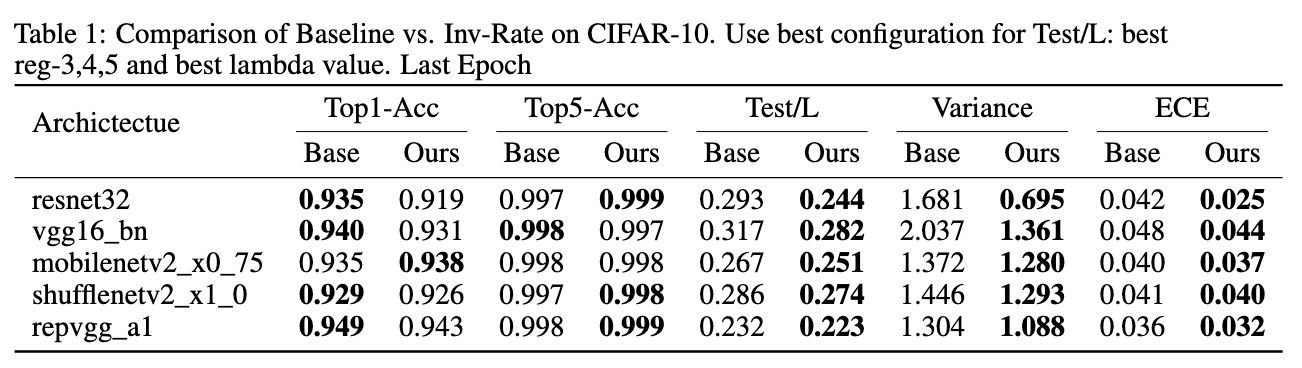

### for cifar100

In [33]:
import pandas as pd
from tabulate import tabulate
df = pd.read_csv("summary_cifar100.csv")
# add 1 col represent the model type (without the reg and lamb)
df["group"] = df["name"].str.split("-").str[0]

In [34]:
# Apply this per group
filtered_df = df.groupby("group", group_keys=False).apply(filter_group)

/tmp/ipykernel_1763546/2835333824.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = df.groupby("group", group_keys=False).apply(filter_group)


In [35]:
selected_cols = ["name",'group','reg', 'lamb',"eval/top1_acc","eval/top5_acc","eval/L", "eval/var","eval/ece"]
df_selected = filtered_df[selected_cols]
df_base= df_selected[df_selected["name"].str.contains("baseline", case=False, na=False)]
df_best= df_selected[~df_selected["name"].str.contains("baseline", case=False, na=False)]
df_base = df_base.drop(columns=["reg", "lamb"])
merged_df = pd.merge(
    df_base, df_best,
    on="group",
    suffixes=("_base", "_best")
)
merged_df = merged_df.drop(columns=["name_best", "name_base"])
print(tabulate(merged_df.head(10),headers='keys'))

    group                eval/top1_acc_base    eval/top5_acc_base    eval/L_base    eval/var_base    eval/ece_base    reg    lamb    eval/top1_acc_best    eval/top5_acc_best    eval/L_best    eval/var_best    eval/ece_best
--  -----------------  --------------------  --------------------  -------------  ---------------  ---------------  -----  ------  --------------------  --------------------  -------------  ---------------  ---------------
 0  mobilenetv2_x0_5                 0.7181                0.9227       1.15164           4.48566        0.115568       5    1                   0.7008                0.9276       1.05704           2.85845        0.0509645
 1  mobilenetv2_x0_75                0.7403                0.9307       1.07645           4.32175        0.110979       5    0.5                 0.7137                0.9302       1.01835           2.90612        0.0611576
 2  mobilenetv2_x1_0                 0.7488                0.9326       1.06336           4.46016        0.1

In [36]:
valid_groups = [
    "resnet32",
    "vgg16_bn",
    "mobilenetv2_x0_75",
    "shufflenetv2_x1_0",
    "repvgg_a1"
]

df=merged_df
df.reset_index(drop=True, inplace=True)
df.set_index("group", inplace=True)
filtered_df=df.reindex(index=valid_groups).drop(columns=["lamb", "reg"])
print(tabulate(filtered_df,headers='keys'))

group                eval/top1_acc_base    eval/top5_acc_base    eval/L_base    eval/var_base    eval/ece_base    eval/top1_acc_best    eval/top5_acc_best    eval/L_best    eval/var_best    eval/ece_best
-----------------  --------------------  --------------------  -------------  ---------------  ---------------  --------------------  --------------------  -------------  ---------------  ---------------
resnet32                         0.6943                0.9105       1.33338           5.87188        0.141517                 0.697                 0.9205       1.1055            3.34394        0.0815266
vgg16_bn                         0.7443                0.9126       1.58586          10.1799         0.184541                 0.714                 0.9026       1.33356           6.35438        0.139304
mobilenetv2_x0_75                0.7403                0.9307       1.07645           4.32175        0.110979                 0.7137                0.9302       1.01835           2.9061

the snapshot from our paper
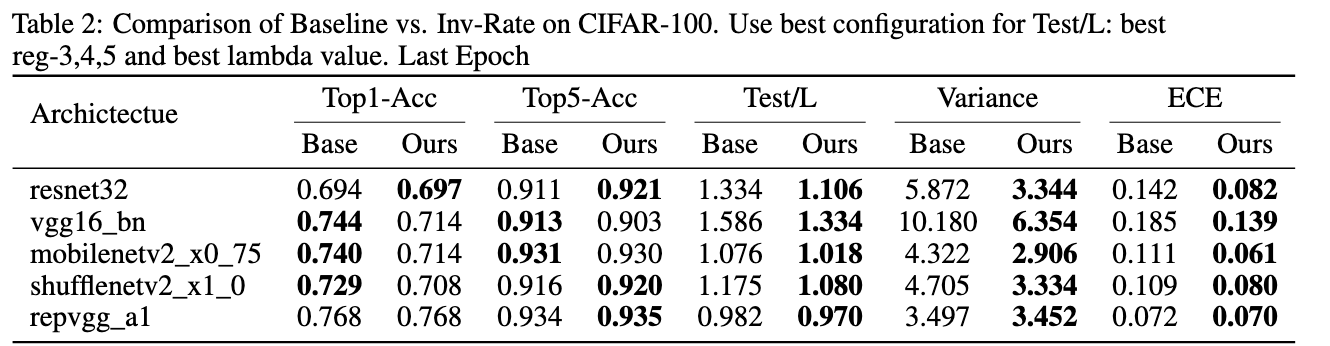